In [1]:
import numpy as np
import pandas as pd
pd.set_option("display.max_columns", None)
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
url = 'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv'

df = pd.read_csv(url)

# Phase 1 : Data Inspection

In [3]:
df.shape

(7043, 21)

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [6]:
pd.DataFrame({
    "Columns" : df.columns,
    "Dtypes" : df.dtypes
})

,Columns,Dtypes
customerID,customerID,str
gender,gender,str
SeniorCitizen,SeniorCitizen,int64
Partner,Partner,str
Dependents,Dependents,str
tenure,tenure,int64
PhoneService,PhoneService,str
MultipleLines,MultipleLines,str
InternetService,InternetService,str
OnlineSecurity,OnlineSecurity,str


In [7]:
df['TotalCharges'].dtype
pd.to_numeric(df['TotalCharges'], errors='coerce').isnull().sum()

np.int64(11)

In [8]:
df.drop(columns=["customerID"] , inplace=True)

In [9]:
cat_cols = df.select_dtypes(include=["str"]).columns.tolist() + ["SeniorCitizen"] 
cat_cols.remove("Churn")
cat_cols

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'SeniorCitizen']

In [10]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
num_cols.remove("SeniorCitizen")
num_cols 

['tenure', 'MonthlyCharges', 'TotalCharges']

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

In [12]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.00,0.000,0.0000,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.000,55.0000,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.50,70.350,89.8500,118.75
TotalCharges,7032.0,2283.300441,2266.771362,18.80,401.45,1397.475,3794.7375,8684.80


In [13]:
pd.DataFrame(df["Churn"].value_counts(normalize=True)).reset_index()

,Churn,proportion
0,No,0.73463
1,Yes,0.26537


In [14]:
num_cols

['tenure', 'MonthlyCharges', 'TotalCharges']

In [15]:
cat_cols

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'SeniorCitizen']

In [16]:
null_count = df[cat_cols + num_cols].isnull().sum()
null_count = null_count[null_count>0]

print(f"Total Null Count in whole Dataset : {null_count}")



Total Null Count in whole Dataset : TotalCharges    11
dtype: int64


# Phase 2 : Target Variable Analysis

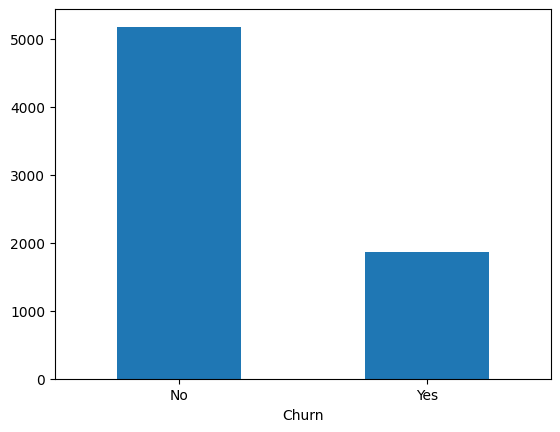

In [17]:
df["Churn"].value_counts().plot(kind="bar")
plt.xticks(rotation=0)
plt.show()

### Class Imblance

In [18]:
imblance_ratio = df["Churn"].value_counts()["No"] / df["Churn"].value_counts()['Yes']
print(f"Class Imblance Ration No/Yes : {imblance_ratio:.3f}")

Class Imblance Ration No/Yes : 2.768


In [19]:
baseline_accuracy = df['Churn'].value_counts(normalize=True).max()
(baseline_accuracy.round(3)) * 100

np.float64(73.5)

# Phase 3 : Numerical Features EDA + Statistical Inference

### Numerical features with target Variable ( Churn(No) v/s Churn(Yes) )

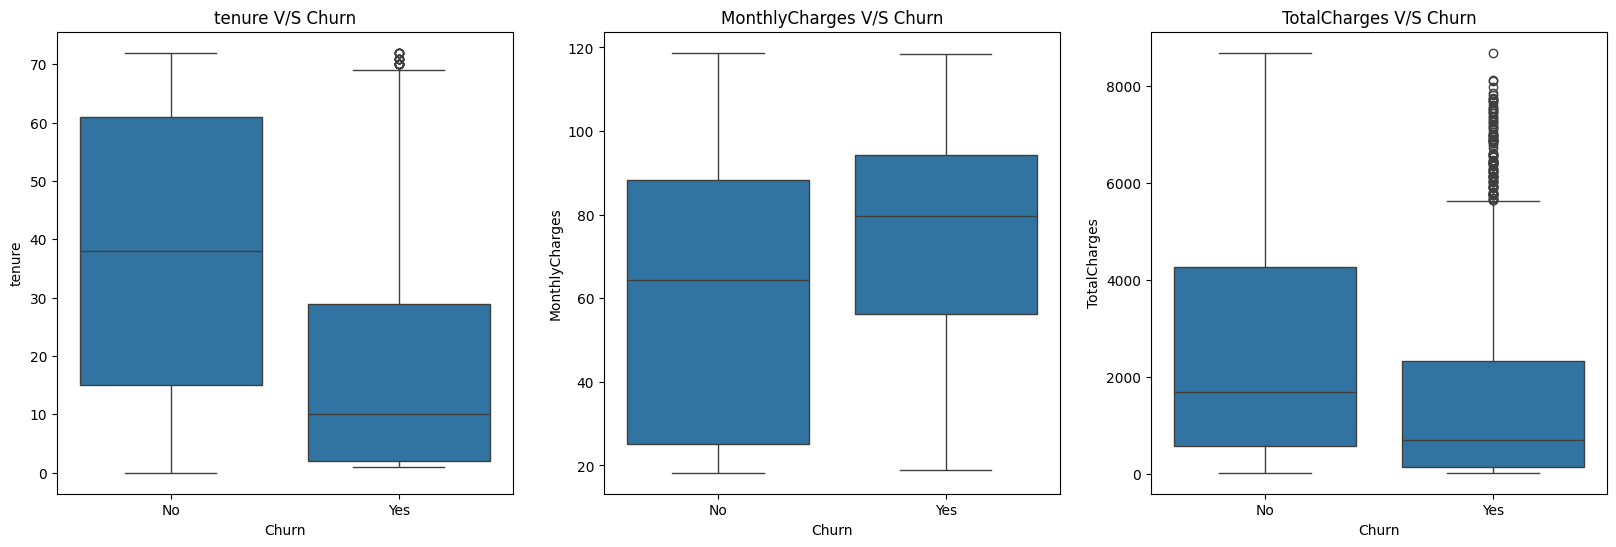

In [20]:
fig , ax = plt.subplots(1 , 3 , figsize=(20 , 6))

ax = ax.flatten()

for i,col in enumerate(num_cols):

    sns.boxplot(
        data = df ,
        x = "Churn",
        y = col,
        ax = ax[i]
    )

    ax[i].set_title(f"{col} V/S Churn")

### T-Test

In [21]:
from scipy.stats import ttest_ind

T_Test = []

for col in num_cols:
    churned = df[ df["Churn"]=="Yes" ][col].dropna()
    not_churned = df[ df["Churn"]=="No" ][col].dropna()
    t_stat , p_value = ttest_ind(churned , not_churned)
    
    T_Test.append({
        "Column" : col,
        "t_stat" : t_stat,
        "p_value" : p_value
    })

pd.DataFrame(T_Test).sort_values("p_value")

,Column,t_stat,p_value
0,tenure,-31.579551,7.999058e-205
2,TotalCharges,-17.068827,4.876866e-64
1,MonthlyCharges,16.536738,2.706646e-60


# Phase 4 : Multicolinearity Check - (VIF)

In [22]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

numeric_df = df[num_cols].dropna()

def calculate_vif(data):
    vif = pd.DataFrame()
    vif['feature'] = data.columns
    vif['VIF'] = [variance_inflation_factor(data.values, i) for i in range(data.shape[1])]
    return vif

numeric_df_reduced = numeric_df.copy()

while True:
    vif_result = calculate_vif(numeric_df_reduced)
    max_vif = vif_result['VIF'].max()
    if max_vif > 10:
        feature_to_drop = vif_result.loc[vif_result['VIF'].idxmax(), 'feature']
        print(f"Dropping '{feature_to_drop}' with VIF = {max_vif:.2f}")
        numeric_df_reduced = numeric_df_reduced.drop(feature_to_drop, axis=1)
    else:
        break

print("\nFinal features after VIF filtering:")
print(calculate_vif(numeric_df_reduced))



Final features after VIF filtering:
          feature       VIF
0          tenure  6.332432
1  MonthlyCharges  3.361075
2    TotalCharges  8.079181


# Phase 5 : Categorical Features EDA + Statistical Inference

#### Step 2: "Expected" Values Calculate Karo — Yeh Core Intuition Hai

Chi-Square ka poora idea hai: **"Agar `Contract` aur `Churn` mein GENUINELY koई relationship na hota (bilkul independent hote), toh yeh table kaisi dikhती?"**

Yeh humारा **baseline/reference point** hai — hum pehले yeh calculate karте hai ki "agar dono variables ka koई lena-dena na hota" toh numbers kaisे distribute hote, phir isse **actual/observed numbers** ke saath compare karenge.

**Formula (expected value har cell ke liye):**

$$E_{ij} = \frac{(\text{Row Total}) \times (\text{Column Total})}{\text{Grand Total}}$$

**Intuition:**

Agar poore dataset mein overall **26.5% log churn** karte hai (yeh humारा "overall churn rate" hai, poori population ka), aur `Contract = Month-to-month` group mein total **3855 log** hai, toh:

- **Agar Contract ka Churn pe koई genuine effect na hota** (independence assumption sach hoti), humein expect karna chahिए ki is group mein bhi **usी 26.5% rate se hi churn ho** — koई zyada, koई kam nahi, kyunki Contract "irrelevant" hota
- Matlab: $3855 \times 0.265 \approx 1021$ log churn karte **(yeh EXPECTED value hai)**

Ab is expected value (1021) ko humare **ACTUAL/OBSERVED data** se compare karenge — agar actual mein sach mein sirf ~1021 log churn kar rahe hai is group mein, toh Contract genuinely irrelevant tha. Lekin agar actual number isse **bahut alag** hai (bahut zyada ya bahut kam), toh yeh signal hai ki Contract genuinely churn ko affect kar raha hai.

#### Step 3: Observed Vs Expected Compare Karo

$$\chi^2 = \sum \frac{(O_{ij} - E_{ij})^2}{E_{ij}}$$

**Intuition:**

Har cell (har row-column combination) ke liye:

1. **"Actual/Observed" ($O_{ij}$) aur "Expected" ($E_{ij}$, agar independence hoti)** ke beech ka **farak** nikalo
2. Is farak ko **square** karo (taaki negative aur positive differences cancel na ho, aur bade differences ko zyada weight mile — bilkul Variance/MSE wale concept jaisa)
3. Ise **$E_{ij}$ se divide** karo (normalize karne ke liye — ek bada absolute-difference bade group mein utna "surprising" nahi hota jitna chhote group mein hota, isliye relative-wise measure karte hai)
4. **Saare cells ke yeh values add** kar do — poore table ka ek single summary number ban jata hai

**Jitna zyada actual, expected se door hai, utна bada Chi-Square statistic** — matlab **utna zyada evidence hai ki genuine relationship hai** (independence wala assumption galat tha, do variables genuinely ek-dusre se juड़े hai).

**Agar $\chi^2 = 0$** hota (perfect case), matlab **har cell mein actual = expected** — bilkul waisा hi jaisa "independence" predict karta, matlab **koई relationship nahi** hai in dono variables mein.

#### Step 4: p-value — Bilkul Wahी Interpretation (Jaisa Hypothesis Testing Mein Hamesha Hota Hai)

- **H0 (Null Hypothesis):** *"Contract aur Churn independent hai"* — matlab poori population mein in dono ka koई genuine association nahi, jo bhi difference sample mein dikha woh random sampling ka luck hai
- **H1 (Alternative Hypothesis):** *"Genuine association hai"* — Contract type genuinely Churn ko influence karta hai

- Agar **p-value chhota hai (< 0.05)** → H0 ko **reject** kar dete hai → statistically confident hai ki **genuine relationship hai**, sirf coincidence nahi
- Agar **p-value bada hai** → H0 reject nahi hota → is feature ka koई reliable signal nahi mila, shayad genuinely independent hai Churn se

**Ek line mein poora concept:** *"Chi-Square Test pehle calculate karta hai ki agar do categorical variables genuinely independent hote toh table kaisi dikhti (Expected values), phir actual/observed table se compare karta hai — jitna zyada farak, utna strong evidence ki genuine association hai, aur p-value batata hai ki yeh farak statistically 'real' hai ya sirf random sampling ka noise."*

In [23]:

from scipy.stats import chi2_contingency

chi2_results = []
for col in cat_cols:
    if col == 'TotalCharges':  # skip, yeh actually numeric hai, cat_cols se already hata dena
        continue
    contingency = pd.crosstab(df[col], df['Churn'])
    chi2_stat, p_value, dof, expected = chi2_contingency(contingency)
    chi2_results.append({'feature': col, 'chi2_stat': chi2_stat, 'p_value': p_value})

chi2_df = pd.DataFrame(chi2_results).sort_values('p_value')
chi2_df

,feature,chi2_stat,p_value
12,Contract,1184.596572,5.863038e-258
6,OnlineSecurity,849.998968,2.661150e-185
9,TechSupport,828.197068,1.443084e-180
5,InternetService,732.309590,9.571788e-160
14,PaymentMethod,648.142327,3.682355e-140
7,OnlineBackup,601.812790,2.079759e-131
8,DeviceProtection,558.419369,5.505219e-122
11,StreamingMovies,375.661479,2.667757e-82
10,StreamingTV,374.203943,5.528994e-82
13,PaperlessBilling,258.277649,4.073355e-58


#### Visualization Step Missing Hai

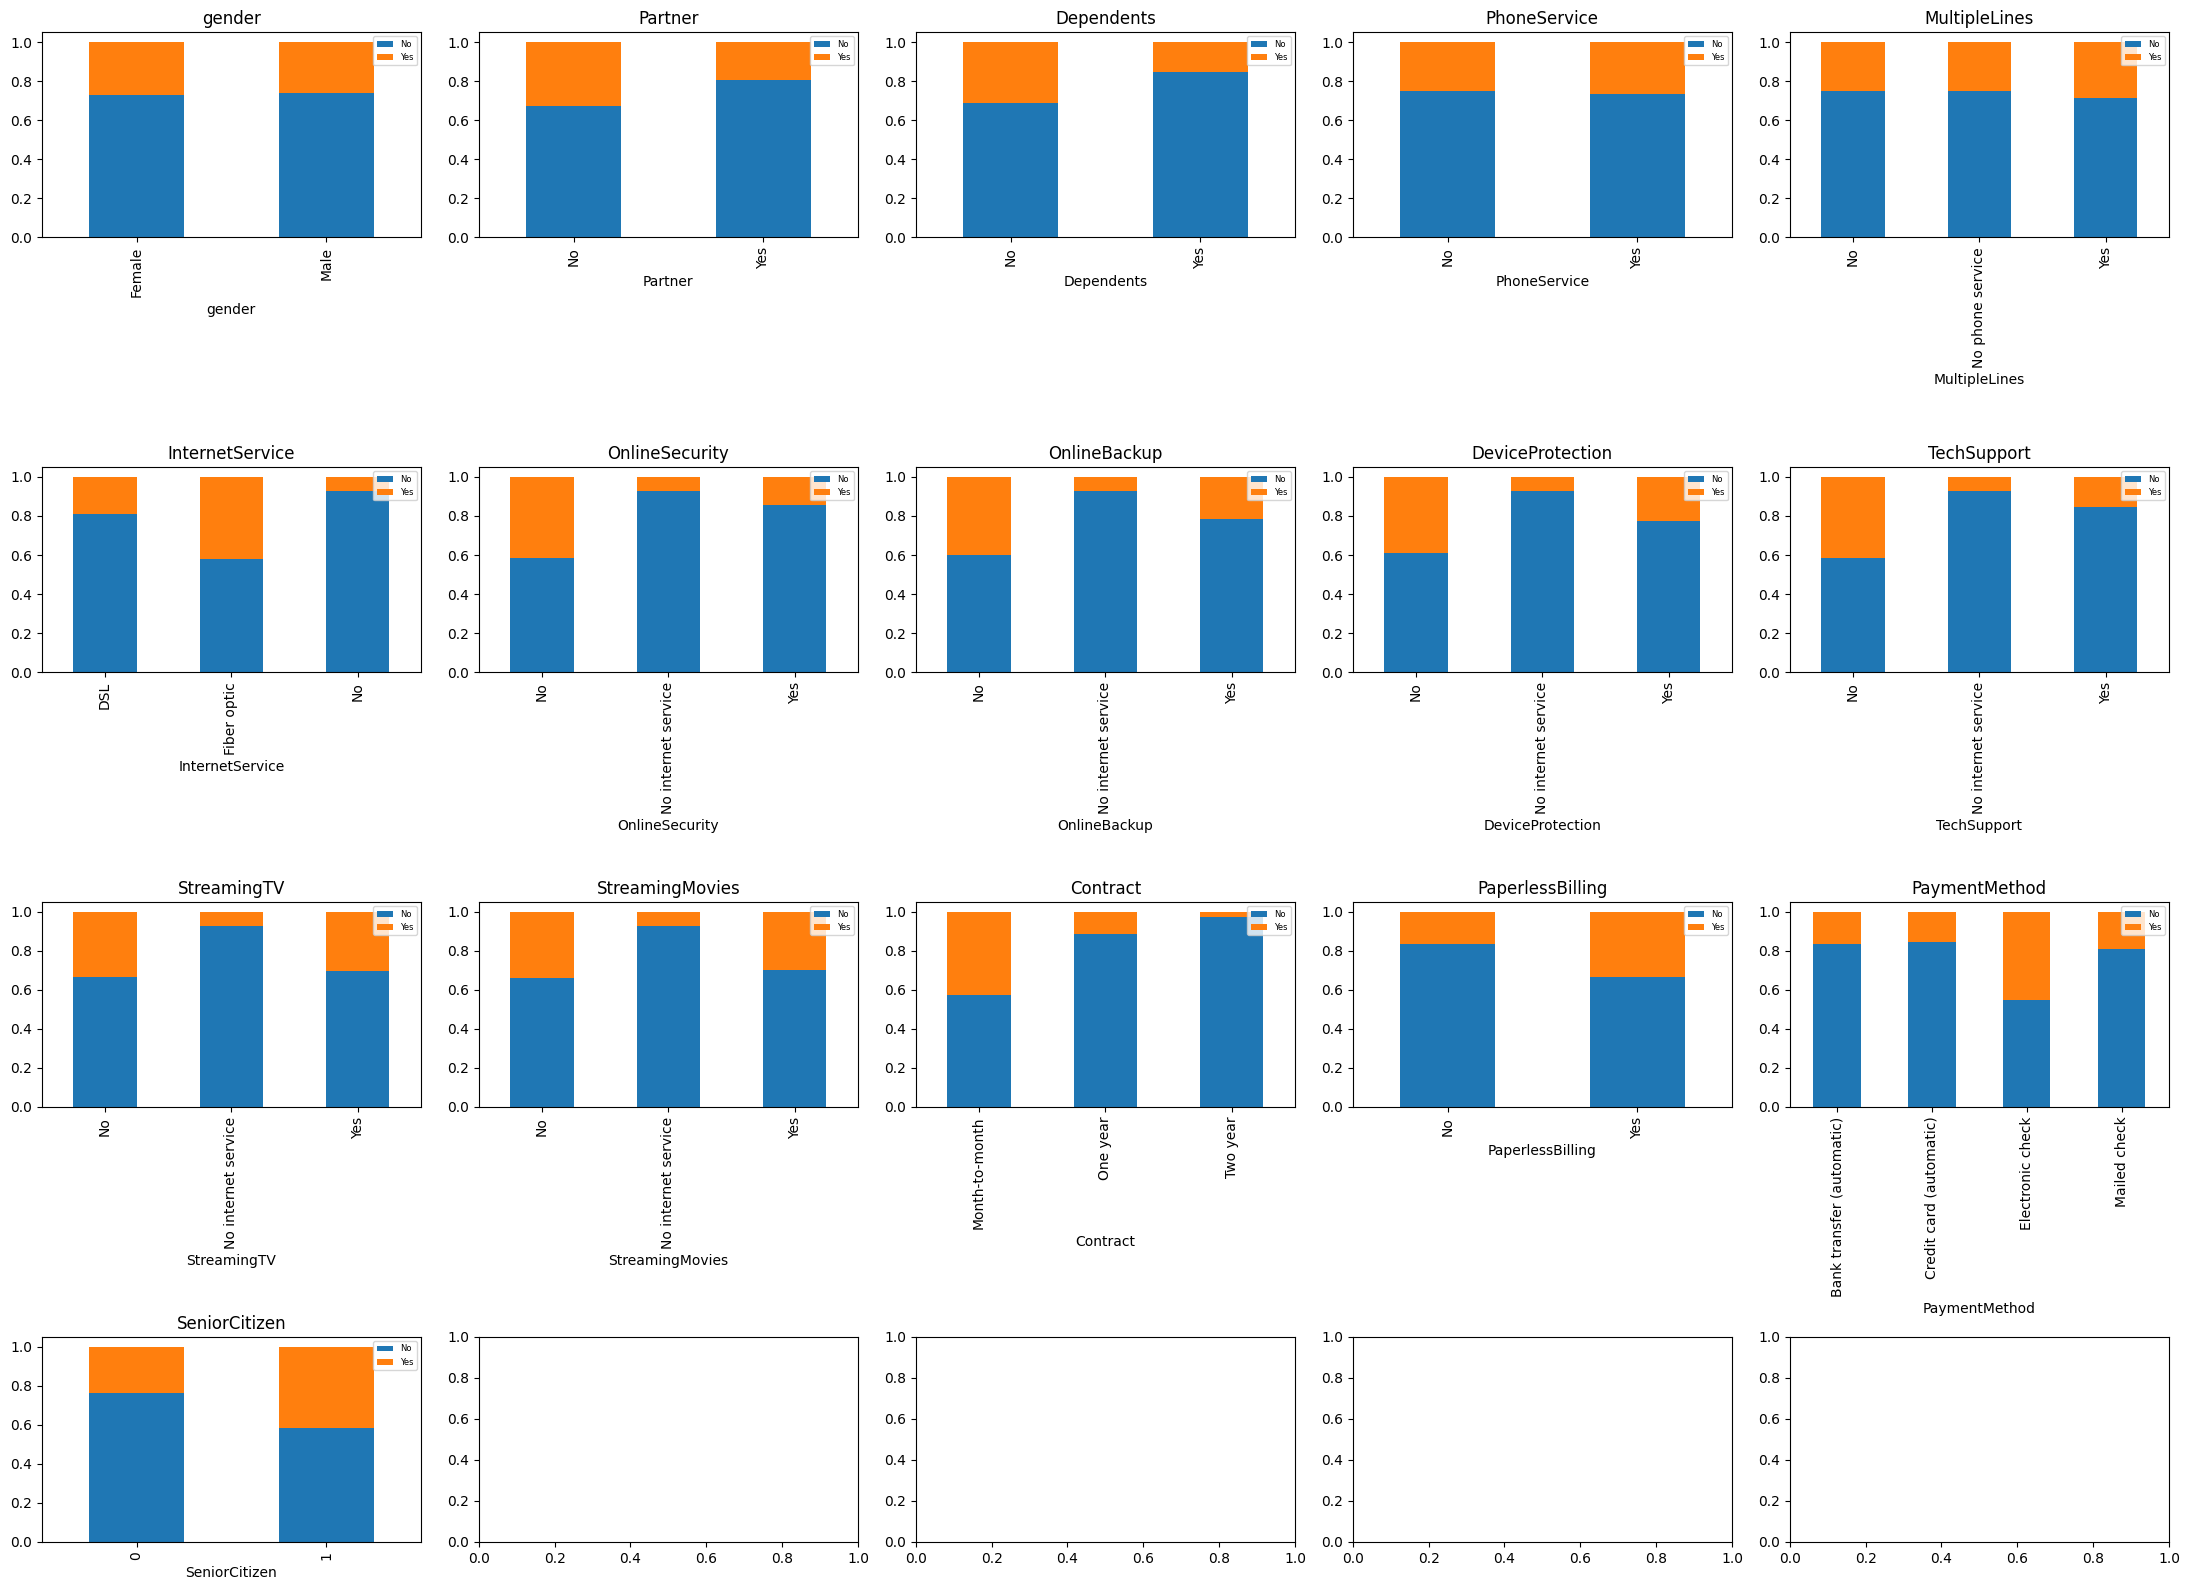

In [24]:
fig, axes = plt.subplots(4, 5, figsize=(22, 16))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    if col == 'TotalCharges':
        continue
    pd.crosstab(df[col], df['Churn'], normalize='index').plot(kind='bar', stacked=True, ax=axes[i])
    axes[i].set_title(col)
    axes[i].legend(loc='upper right', fontsize=6)

plt.tight_layout()
plt.show()

# Phase 6: Missing Value Handling

In [25]:
df['TotalCharges'].isnull().sum()

np.int64(11)

In [26]:
df[df['TotalCharges'].isnull()][['tenure', 'MonthlyCharges', 'TotalCharges']]

,tenure,MonthlyCharges,TotalCharges
488,0,52.55,NaN
753,0,20.25,NaN
936,0,80.85,NaN
1082,0,25.75,NaN
1340,0,56.05,NaN
3331,0,19.85,NaN
3826,0,25.35,NaN
4380,0,20.00,NaN
5218,0,19.70,NaN
6670,0,73.35,NaN


In [27]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [28]:
df['TotalCharges'].isnull().sum()   # 0 aana chahiye ab
df.isnull().sum()[df.isnull().sum() > 0]   # empty hona chahiye

Series([], dtype: int64)

# Phase 7 : Feature Engineering

In [29]:
df['AvgChargePerMonth'] = df['TotalCharges'] / df['tenure'].replace(0, 1)

"""
Yeh ek "discount/deviation indicator" ban sakta hai — agar customer ka AvgChargePerMonth uske current MonthlyCharges se bahut alag hai, matlab uski billing history mein koi anomaly/change hua hai (jaise plan upgrade/downgrade) — yeh naya signal ho sakta hai jo raw TotalCharges nahi deta.
"""

df['ChargeDeviation'] = df['MonthlyCharges'] - df['AvgChargePerMonth']
"""
kya log jada pay kar rha hai apne Avg monthly charges se to +ve agar kam pay kar rha hai to -ve
"""

print("New Features 'AvgChargePerMonth' And 'ChargeDeviation' are created")


New Features 'AvgChargePerMonth' And 'ChargeDeviation' are created


In [30]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,AvgChargePerMonth,ChargeDeviation
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,29.850000,0.000000
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,55.573529,1.376471
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,54.075000,-0.225000
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,40.905556,1.394444
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,75.825000,-5.125000


#### Binary Categorical Features Encoding

In [31]:
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

#### "No internet service" / "No phone service" Wala Special Case — Zaroori Observation

In [32]:
df['OnlineSecurity'].unique()
# ['Yes', 'No', 'No internet service']

<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

In [33]:
service_cols = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
    'TechSupport', 'StreamingTV', 'StreamingMovies'
    ]

for col in service_cols:
    df[col] = df[col].replace('No internet service', 'No')

In [34]:
df['MultipleLines'] = df['MultipleLines'].replace('No phone service', 'No')

#### new Feature — "TotalServices"

In [35]:
service_cols = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

df['TotalServices'] = 0
for col in service_cols:
    df['TotalServices'] += (df[col] == 'Yes').astype(int)

#### Nominal Encoding — Multi-Category Features

In [36]:
nominal_cols = ['InternetService', 'Contract', 'PaymentMethod', 'MultipleLines'] + service_cols
df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)

#### Scaling of numeric features

In [37]:
from sklearn.model_selection import train_test_split

X = df.drop("Churn" , axis=1)
y = df["Churn"]

X_train , X_test , y_train , y_test = train_test_split(
    X , y ,
    stratify=y,
    test_size=0.3 ,
    random_state=42
)

In [38]:
y_train.value_counts(normalize=True)
y_test.value_counts(normalize=True)

Churn
0    0.734501
1    0.265499
Name: proportion, dtype: float64

In [39]:
from sklearn.preprocessing import StandardScaler

numeric_cols_final = ['tenure', 'MonthlyCharges', 'TotalCharges', 'TotalServices']

scaler = StandardScaler()

X_train[numeric_cols_final] = scaler.fit_transform(X_train[numeric_cols_final])

X_test[numeric_cols_final] = scaler.transform(X_test[numeric_cols_final])

In [40]:
X_train['gender'] = X_train['gender'].map({'Male': 1, 'Female': 0})
X_test['gender'] = X_test['gender'].map({'Male': 1, 'Female': 0})

# Phase 8: Scratch Implementation (Sigmoid + Gradient Descent + Log-Loss)

#### Data Preperation

In [41]:
import numpy as np

X_train_arr = X_train.values.astype(float)
X_test_arr = X_test.values.astype(float)
y_train_arr = y_train.values.astype(float)
y_test_arr = y_test.values.astype(float)

# Intercept column add karo (yaad hai Linear Regression se — bias ke liye)
X_train_b = np.c_[np.ones((X_train_arr.shape[0], 1)), X_train_arr]
X_test_b = np.c_[np.ones((X_test_arr.shape[0], 1)), X_test_arr]

#### Sigmoid Function

In [42]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

#### Log-Loss

In [43]:
def compute_cost(y_true, y_pred):
    m = len(y_true)
    epsilon = 1e-15  # zaroori hai — log(0) avoid karne ke liye
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    cost = -(1/m) * np.sum(y_true*np.log(y_pred) + (1-y_true)*np.log(1-y_pred))
    return cost

#### Training : Gradient Descent

In [44]:
def gradient_descent(X, y, learning_rate=0.01, n_iterations=2000):
    m, n = X.shape
    w = np.zeros(n)
    cost_history = []
    
    for i in range(n_iterations):
        z = X @ w
        y_pred = sigmoid(z)
        
        error = y_pred - y
        gradient = (1/m) * (X.T @ error)
        
        w = w - learning_rate * gradient
        
        cost = compute_cost(y, y_pred)
        cost_history.append(cost)
        
        if i % 200 == 0:
            print(f"Iteration {i}: Cost = {cost:.6f}")
    
    return w, cost_history

w_scratch, cost_history = gradient_descent(X_train_b, y_train_arr, learning_rate=0.1, n_iterations=10000)

Iteration 0: Cost = 0.693147
Iteration 200: Cost = 9.163666
Iteration 400: Cost = 14.700105
Iteration 600: Cost = 9.000720
Iteration 800: Cost = 9.163681
Iteration 1000: Cost = 12.886119
Iteration 1200: Cost = 8.410442
Iteration 1400: Cost = 9.163288
Iteration 1600: Cost = 16.994018
Iteration 1800: Cost = 14.939592
Iteration 2000: Cost = 6.934380
Iteration 2200: Cost = 4.274896
Iteration 2400: Cost = 5.470947
Iteration 2600: Cost = 4.127029
Iteration 2800: Cost = 9.047813
Iteration 3000: Cost = 4.449282
Iteration 3200: Cost = 9.111847
Iteration 3400: Cost = 9.158762
Iteration 3600: Cost = 4.003253
Iteration 3800: Cost = 4.115192
Iteration 4000: Cost = 4.653741
Iteration 4200: Cost = 5.816494
Iteration 4400: Cost = 4.122331
Iteration 4600: Cost = 9.162457
Iteration 4800: Cost = 13.977810
Iteration 5000: Cost = 8.071122
Iteration 5200: Cost = 9.159383
Iteration 5400: Cost = 8.702566
Iteration 5600: Cost = 9.028159
Iteration 5800: Cost = 9.085444
Iteration 6000: Cost = 4.290173
Iteration 

#### Cost History Plot

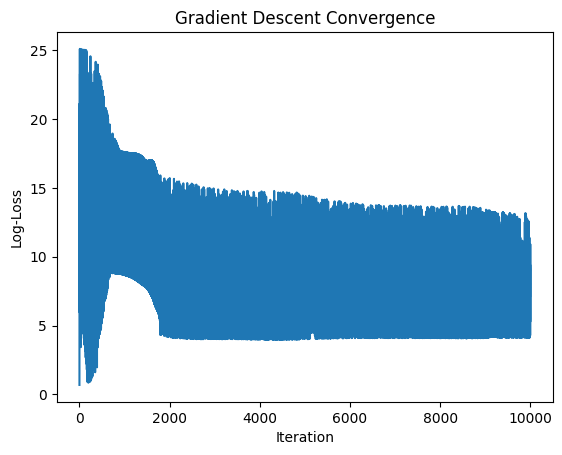

In [45]:
plt.plot(cost_history)
plt.xlabel('Iteration')
plt.ylabel('Log-Loss')
plt.title('Gradient Descent Convergence')
plt.show()

#### Prediction

In [46]:
def predict(X, w, threshold=0.5):
    probabilities = sigmoid(X @ w)
    return (probabilities >= threshold).astype(int), probabilities

y_pred_train, y_prob_train = predict(X_train_b, w_scratch)
y_pred_test, y_prob_test = predict(X_test_b, w_scratch)

#### Sanity Check — Accuracy

In [47]:
train_accuracy = np.mean(y_pred_train == y_train_arr)
test_accuracy = np.mean(y_pred_test == y_test_arr)
print(f"Train Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Train Accuracy: 0.7974
Test Accuracy: 0.8008


# Phase 9 : sklearn Implementation

#### Model Training

In [48]:
from sklearn.linear_model import LogisticRegression

sklearn_model = LogisticRegression(max_iter=1000)
sklearn_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

#### Observe Coefficent and Intercept

In [49]:
print("Intercept:", sklearn_model.intercept_)
print("Coefficients:", sklearn_model.coef_)

Intercept: [-0.39557415]
Coefficients: [[ 0.02513554  0.14673831 -0.00709502 -0.26195169 -1.311623   -0.34847677
   0.41434516  0.33393144  0.62402112 -0.01650908 -0.02459901 -0.01869428
   0.81896621 -1.04308011 -0.72196984 -1.29433427 -0.03880731  0.37552133
   0.08201402  0.30715977 -0.39043502 -0.14901519 -0.02591811 -0.33612184
   0.22647596  0.31761867]]


#### Prediction

In [50]:
# Class predictions (0/1)
y_pred_sklearn = sklearn_model.predict(X_test)

# Probability predictions (evaluation ke liye zaroori honगе — ROC/PR curve)
y_prob_sklearn = sklearn_model.predict_proba(X_test)[:, 1]

#### Scratch vs Sklearn

In [51]:
sklearn_accuracy = sklearn_model.score(X_test, y_test)
print(f"Sklearn Test Accuracy: {sklearn_accuracy:.4f}")

Sklearn Test Accuracy: 0.8107


In [52]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

y_prob_scratch = sigmoid(X_test_b @ w_scratch)
y_pred_scratch = (y_prob_scratch >= 0.5).astype(int)

scratch_accuracy = np.mean(y_pred_scratch == y_test_arr)
print(f"Scratch Test Accuracy: {scratch_accuracy:.4f}")

Scratch Test Accuracy: 0.8008


In [53]:
comparison = pd.DataFrame({
    'Feature': X_train.columns,
    'Scratch_Weight': w_scratch[1:],   # [0] intercept tha
    'Sklearn_Weight': sklearn_model.coef_[0]
})
print(comparison)

                                  Feature  Scratch_Weight  Sklearn_Weight
0                                  gender       -1.467234        0.025136
1                           SeniorCitizen        6.201398        0.146738
2                                 Partner       -3.648196       -0.007095
3                              Dependents       -7.108112       -0.261952
4                                  tenure      -18.710376       -1.311623
5                            PhoneService       -9.005054       -0.348477
6                        PaperlessBilling        8.187677        0.414345
7                          MonthlyCharges       18.232677        0.333931
8                            TotalCharges      -15.685288        0.624021
9                       AvgChargePerMonth       -0.313192       -0.016509
10                        ChargeDeviation       -0.610120       -0.024599
11                          TotalServices       -5.468983       -0.018694
12            InternetService_Fiber op

# Phase 10 : Evaluation (Confusion Matrix, Precision, Recall, F1, ROC-AUC, PR-AUC)

#### Confusion Matrix

[[1399  153]
 [ 247  314]]


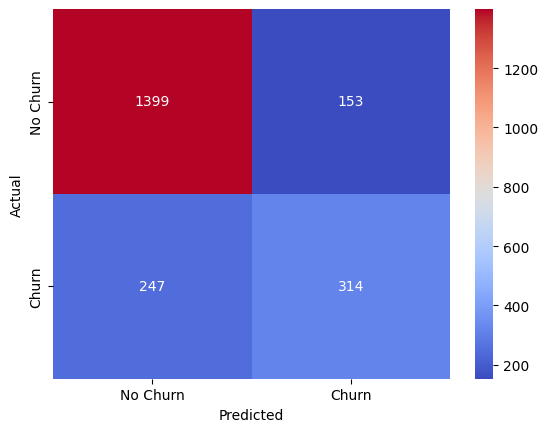

In [54]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


cm = confusion_matrix(y_test, y_pred_sklearn)
print(cm)

sns.heatmap(
    cm, annot=True, fmt='d', 
    cmap="coolwarm",
    xticklabels=['No Churn', 'Churn'],
    yticklabels=['No Churn', 'Churn']
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

plt.show()

#### Classification Report

In [55]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_sklearn, target_names=['No Churn', 'Churn']))

              precision    recall  f1-score   support

    No Churn       0.85      0.90      0.87      1552
       Churn       0.67      0.56      0.61       561

    accuracy                           0.81      2113
   macro avg       0.76      0.73      0.74      2113
weighted avg       0.80      0.81      0.80      2113



In [56]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("Precision (Churn):", precision_score(y_test, y_pred_sklearn))
print("Recall (Churn):", recall_score(y_test, y_pred_sklearn))
print("F1-Score (Churn):", f1_score(y_test, y_pred_sklearn))

Precision (Churn): 0.6723768736616702
Recall (Churn): 0.5597147950089126
F1-Score (Churn): 0.6108949416342413


#### ROC-AUC Aur PR-AUC

In [57]:
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve

roc_auc = roc_auc_score(y_test, y_prob_sklearn)
pr_auc = average_precision_score(y_test, y_prob_sklearn)

print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC: {pr_auc:.4f}")

ROC-AUC: 0.8448
PR-AUC: 0.6419


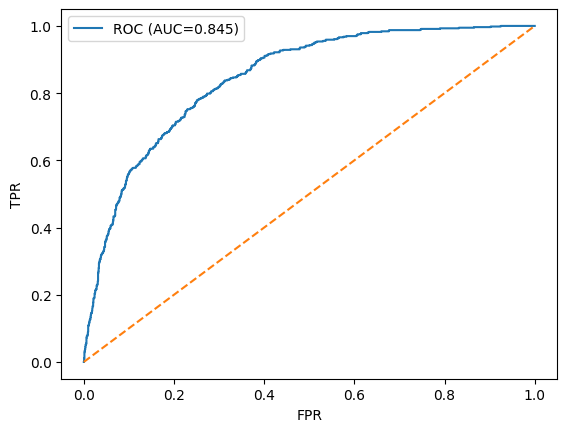

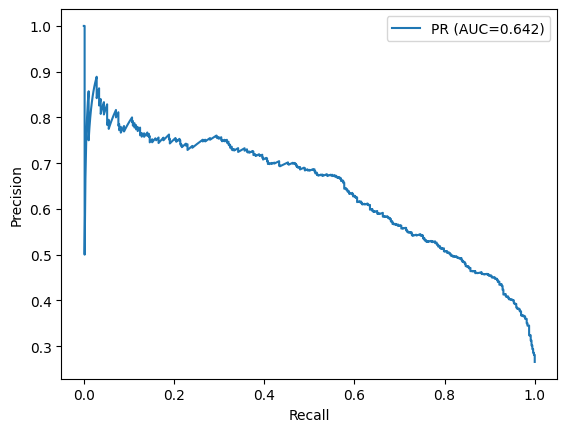

In [58]:
fpr, tpr, _ = roc_curve(y_test, y_prob_sklearn)
plt.plot(fpr, tpr, label=f'ROC (AUC={roc_auc:.3f})')
plt.plot([0,1],[0,1],'--')
plt.xlabel('FPR'); plt.ylabel('TPR'); plt.legend()
plt.show()

precisions, recalls, _ = precision_recall_curve(y_test, y_prob_sklearn)
plt.plot(recalls, precisions, label=f'PR (AUC={pr_auc:.3f})')
plt.xlabel('Recall'); plt.ylabel('Precision'); plt.legend()
plt.show()

In [59]:
metrics_comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC'],
    'Scratch': [
        np.mean(y_pred_scratch == y_test_arr),
        precision_score(y_test_arr, y_pred_scratch),
        recall_score(y_test_arr, y_pred_scratch),
        f1_score(y_test_arr, y_pred_scratch),
        roc_auc_score(y_test_arr, y_prob_scratch)
    ],
    'Sklearn': [
        sklearn_model.score(X_test, y_test),
        precision_score(y_test, y_pred_sklearn),
        recall_score(y_test, y_pred_sklearn),
        f1_score(y_test, y_pred_sklearn),
        roc_auc_score(y_test, y_prob_sklearn)
    ]
})
print(metrics_comparison)

      Metric   Scratch   Sklearn
0   Accuracy  0.800757  0.810696
1  Precision  0.644628  0.672377
2     Recall  0.556150  0.559715
3         F1  0.597129  0.610895
4    ROC-AUC  0.825489  0.844825


# Phase 11 : Threshold Tuning

#### Matrix at different Thresholds

In [60]:
from sklearn.metrics import precision_score, recall_score, f1_score

for threshold in [0.5, 0.4, 0.3, 0.25, 0.2]:
    y_pred_custom = (y_prob_sklearn >= threshold).astype(int)
    prec = precision_score(y_test, y_pred_custom)
    rec = recall_score(y_test, y_pred_custom)
    f1 = f1_score(y_test, y_pred_custom)
    print(f"Threshold={threshold}: Precision={prec:.3f}, Recall={rec:.3f}, F1={f1:.3f}")

Threshold=0.5: Precision=0.672, Recall=0.560, F1=0.611
Threshold=0.4: Precision=0.577, Recall=0.679, F1=0.624
Threshold=0.3: Precision=0.529, Recall=0.765, F1=0.625
Threshold=0.25: Precision=0.502, Recall=0.811, F1=0.620
Threshold=0.2: Precision=0.471, Recall=0.856, F1=0.607


#### Finding best Threshold Visually through Precision-Recall Curve

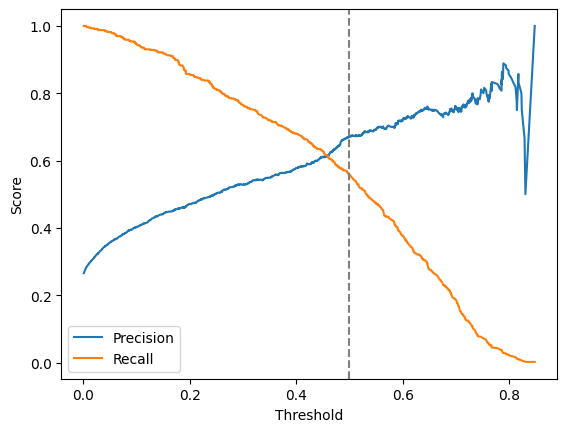

In [61]:
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob_sklearn)

plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.legend()
plt.axvline(x=0.5, color='gray', linestyle='--', label='default')
plt.show()

#### Business Decision — Final Threshold

In [62]:
final_threshold = 0.35
y_pred_final = (y_prob_sklearn >= final_threshold).astype(int)
print(classification_report(y_test, y_pred_final, target_names=['No Churn', 'Churn']))

              precision    recall  f1-score   support

    No Churn       0.89      0.79      0.83      1552
       Churn       0.55      0.72      0.62       561

    accuracy                           0.77      2113
   macro avg       0.72      0.75      0.73      2113
weighted avg       0.80      0.77      0.78      2113

